<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/healthcare/BUSI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast cancer
These are images comming from patients
What is breast cancer?
these are Ultra sound image
Why we study ultra sound images?
Clienical chalange --> present the physical images
Distribution in the breast,



Aim for the 3rd project
1. **Train a CNN to detect the mask**
* Yaloo -- CNN type
* A bounding box around the image & put mask
* mask is contorn radiology

After you undrestand what is the imag
2. **After detection**
* Filter the image
3. **Automatically segment(generate contorn)**
Object segmentation
* UNET --> CNN type

4. **Classify delassion into ordintion**


In [ ]:
# Train 3 diffirent model
# 1- model to detect the bounding box(Object detection)
    # * Find the bounding box of the contour--> this is your label for the datast
    # * Split the dataset in trainning and testing dataset

# 2- model to detect the contours
# 3- model to classify(final one) (malignant or benign)

In [1]:
from google.colab import drive
import os
import matplotlib.pyplot as plt
import matplotlib.image as pltimg
import numpy as np
import cv2
import torch
import re
from PIL import Image
from torchvision import transforms
from torch import nn
from time import time

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
# connect to drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [4]:
path="/content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip"

In [ ]:
!unzip /content/drive/MyDrive/Healthcare/BUSI/BUSI_Jpeg.zip

### Task 1. Read an ultra image with respect column ->
* See the images and the mask
*  white is for boun tesho
* black is for soft tesho of the mask

In [6]:
data_path = ['benign', 'benign_mask', 'malignant', 'malignant_mask']

# check the files and folders
for path in data_path:
  for root, dirs, files in os.walk(path):
    print(f'There are {len(dirs)} directories and  {len(files)} files in "/{root}"')

There are 0 directories and  437 files in "/benign"
There are 0 directories and  455 files in "/benign_mask"
There are 0 directories and  210 files in "/malignant"
There are 0 directories and  212 files in "/malignant_mask"


In [7]:

def extract_idx(filename):
  """
  Extract index from the filename
  """
  index = re.search(r'\((\d+)\)', filename)
  if index is not None:
    return int(index.group(1))
  else: return -1

def is_valid_image(filename, prefix, is_mask=False):
  """
  Make sure the file and the pattern in the dataset match in order to avoid duplicate images
  """
  if is_mask:
    pattern = rf'{prefix} \(\d+\)_mask\.png$'
  else:
      pattern = rf'{prefix} \(\d+\)\.png$'
  return re.match(pattern, filename)

In [8]:
"""
  Clean up the images directories
  read all images in the directory -> extract only images by index in the file -> validate to remove duplicate or invalid image
  sort them based on the index
"""
benign = sorted(
    [f for f in os.listdir('benign') if extract_idx(f) != -1 and is_valid_image(f, 'benign', False)],
    key=extract_idx)
benign_mask = sorted(
    [f for f in os.listdir('benign_mask') if extract_idx(f) != -1 and is_valid_image(f, 'benign', True)],
    key=extract_idx)
malignant = sorted(
    [f for f in os.listdir('malignant') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', False)],
    key=extract_idx)
malignant_mask = sorted(
    [f for f in os.listdir('malignant_mask') if extract_idx(f) != -1 and is_valid_image(f, 'malignant', True)],
    key=extract_idx)

In [9]:
len(benign), len(benign_mask), len(malignant), len(malignant_mask)

(437, 437, 210, 210)

In [10]:
# plot a random image from each classes
def plot_img_with_mask(depth, root):
  idx = np.random.randint(0, depth)
  fig, ax = plt.subplots(1, 5, figsize=(15, 4))

  # orignal image
  org_img = pltimg.imread(f'{root}/{root} ({idx}).png')
  # mask image
  mask_img = pltimg.imread(f'{root}_mask/{root} ({idx})_mask.png')

  # plot orinal img
  ax[0].imshow(org_img)
  ax[0].set_title(f"Orignal {root} ({idx})")
  ax[0].set_xticks([])
  ax[0].set_yticks([])

  # plot the mask img
  ax[1].imshow(mask_img)
  ax[1].set_title(f"Mask {root} ({idx})")
  ax[1].set_xticks([])
  ax[1].set_yticks([])


  print(f'maks_img shape: {mask_img.shape}')

  # add threshold for the mask image
  if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
    imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask_img

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
  contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

  # plot the contours image
  contours_img = cv2.drawContours(mask_img, contours, -1, (127,255,0), 2)
  ax[2].imshow(contours_img)
  ax[2].set_title(f"Contours {root} ({idx})")
  ax[2].set_xticks([])
  ax[2].set_yticks([])

  # masked the original image
  controus_img = org_img.copy()
  contours_org_img = cv2.drawContours(controus_img, contours, -1, (127, 255, 0), 2)
  ax[3].imshow(contours_org_img)
  ax[3].set_title(f'Masked {root} ({idx})', color='red')
  ax[3].set_xticks([])
  ax[3].set_yticks([])

  # Contours bounding box
  bound_img = org_img.copy()
  for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(bound_img, (x, y), (x+w, y+h), (0, 255, 0, 0), 4)
  ax[4].imshow(bound_img)
  ax[4].set_title(f'Bounding Contours {root} ({idx})', color='red')
  ax[4].set_xticks([])
  ax[4].set_yticks([])

  plt.tight_layout()


maks_img shape: (328, 544)
maks_img shape: (494, 545)


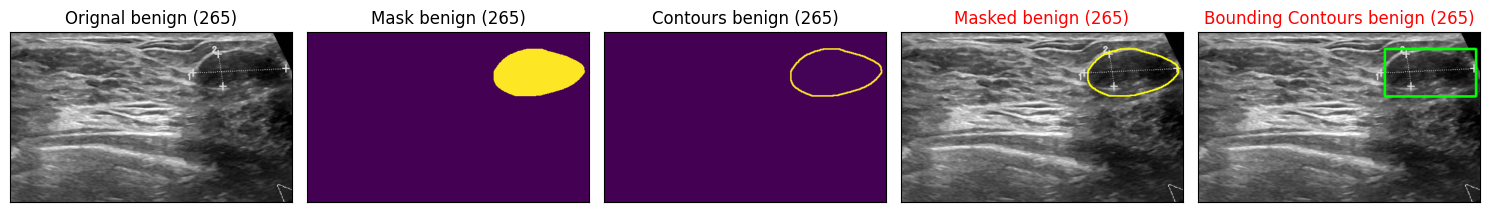

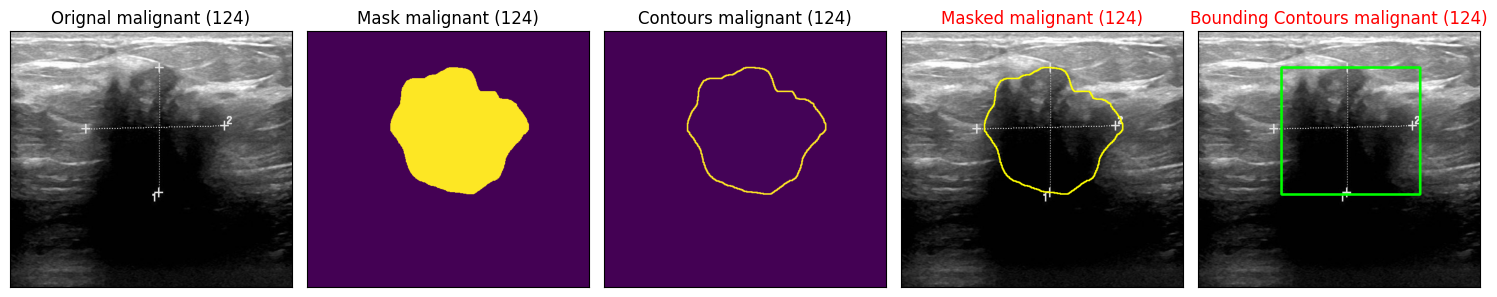

In [11]:
plot_img_with_mask(len(benign), 'benign')
plot_img_with_mask(len(malignant), 'malignant')

In [ ]:
# add threshold for the mask image
# orignal image
org_img = pltimg.imread(f'benign/benign (5).png')
# mask image
mask_img = pltimg.imread(f'benign_mask/benign (5)_mask.png')

if len(mask_img.shape) == 3: # <-- if the image is not already in 1 chanel(gray scale)
  imgray = cv2.cvtColor(mask_img, cv2.COLOR_BGR2GRAY)
else:
  imgray = mask_img

imgray = (imgray * 255).astype("uint8") # <-- change image type
_, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)



In [ ]:
contours_org_img = cv2.drawContours(org_img, contours, -1, (127, 255, 0), 2)
for cnt in contours:
  x, y, w, h = cv2.boundingRect(cnt)
  print(x, y, w, h)
  cv2.rectangle(contours_org_img, (x, y), (x + w, y + h), (0, 255, 0), 2)



222 190 73 59


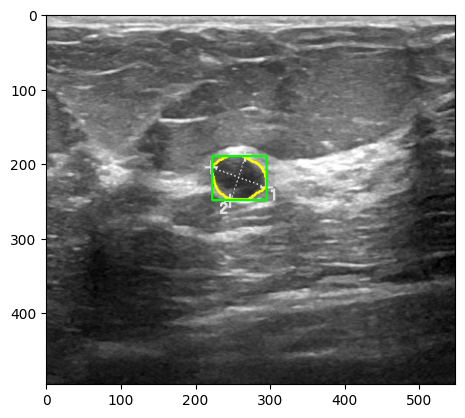

In [ ]:
plt.imshow(contours_org_img)

In [ ]:
len(benign), len(benign_mask), len(malignant), len(malignant_mask)


(437, 437, 210, 210)

In [11]:
def get_bbox_and_cnt(mask):
  if len(mask.shape) == 3:
    imgray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
  else:
    imgray = mask

  imgray = (imgray * 255).astype("uint8") # <-- change image type
  _, threshold = cv2.threshold(imgray, 127, 255, cv2.THRESH_BINARY)

  # get the contours
  contours, _ = cv2.findContours(threshold,  cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
  if len(contours)==0:
    return None

  # take the largest contour
  cnt = max(contours, key=cv2.contourArea)
  # get the bounding box
  x, y, w, h = cv2.boundingRect(cnt)

  return contours, [x, y, w, h]


In [12]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self, img_list, mask_list, img_dir, mask_dir, transform = None, image_size = None):
    self.img_list = img_list
    self.mask_list = mask_list
    self.img_dir = img_dir
    self.mask_dir = mask_dir
    self.transform = transform
    self.image_size = image_size

  def __len__(self):
    return len(self.img_list)

  def __getitem__(self, index):
    image_path = os.path.join(self.img_dir, self.img_list[index])
    mask_path = os.path.join(self.mask_dir, self.mask_list[index])

    image = Image.open(image_path).convert("RGB")

    # original size
    w_orig, h_orig = image.size

    mask = Image.open(mask_path)

    if self.transform:
      image = self.transform(image)

    _, bbox = get_bbox_and_cnt(np.array(mask))
    if bbox is None:
      bbox = [0, 0, 0, 0]
    # if the image is size is changed then make sure to change the bounding box geometry too
    if self.image_size:
      w_new, h_new = self.image_size, self.image_size
      scale_x = w_new / w_orig
      scale_y = h_new / h_orig
      x, y, w, h = bbox
      bbox = [
          x * scale_x,
          y * scale_y,
          w * scale_x,
          h * scale_y
      ]
    return image, torch.tensor(bbox, dtype=torch.float32)


In [14]:
img_size = 224
# create a transformer
transform_pipeline = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])
benign_dataset = Dataset(benign, benign_mask, 'benign', 'benign_mask', transform=transform_pipeline, image_size=img_size)
malignant_dataset = Dataset(malignant, malignant_mask, 'malignant', 'malignant_mask', transform=transform_pipeline)


In [15]:
start_time = time()
for i in range(len(benign_dataset)):
    image, bbox = benign_dataset[i]   # <-- NOW data is loaded

    torch.save((image, bbox), f"data/benign_{i}.pt", )
print(f'tokes {time()-start_time}s')

tokes 5.426143646240234s


In [16]:
class CachedDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir):
        self.files = os.listdir(data_dir)
        self.data_dir = data_dir

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.data_dir, self.files[idx])
        image, bbox = torch.load(path)
        return image, bbox

In [17]:
cached_dataset = CachedDataset("data")
len(cached_dataset)

437

In [18]:
# splitting the Benign to training and testing
train_size = int(0.7 * len(cached_dataset)) # 70%
valid_size = int(0.2 * len(cached_dataset)) # 20%
test_size = len(cached_dataset)-train_size-valid_size # 10%
ben_train_dataset, ben_valid_dataset, ben_test_dataset = torch.utils.data.random_split(cached_dataset, [train_size, valid_size, test_size])

In [19]:
# add data loader
ben_train_loader = torch.utils.data.DataLoader(dataset=ben_train_dataset, batch_size=32, num_workers=2, shuffle=True, drop_last=True)
ben_valid_loader = torch.utils.data.DataLoader(dataset=ben_valid_dataset, batch_size=32, num_workers=2, shuffle=True)
ben_test_loader = torch.utils.data.DataLoader(dataset=ben_test_dataset, batch_size=32, num_workers=2, shuffle=False)

In [76]:
box

tensor([464.,  90., 146.,  99.])

((224, 224, 3), tensor([78.1210, 51.4405, 30.6904, 24.7850]))

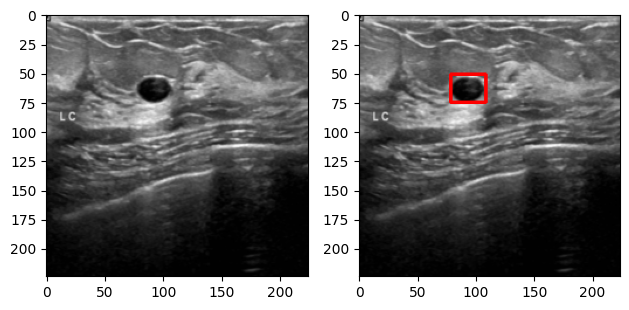

In [20]:
img, box = ben_test_loader.dataset.dataset.__getitem__(4)

img = img.permute(1,2,0).cpu().numpy()
x, y, w, h = map(lambda x: int(x), box)

_, ax = plt.subplots(1,2)
ax[0].imshow(img)
bound_img = cv2.rectangle(img.copy(),
                          (x, y),
                          (x+w, y+h),
                          (255, 0, 0),
                          2)
ax[1].imshow(bound_img)
plt.tight_layout()
img.shape, box


In [21]:
# Builing the network
class Cnn_network(nn.Module):
  def __init__(self, num_class):
    super(Cnn_network, self).__init__()
    self.conv1 = nn.Conv2d(3, 164, 3)
    self.bn1 = nn.BatchNorm2d(164)

    self.conv2 = nn.Conv2d(164, 80, 3)
    self.bn2 = nn.BatchNorm2d(80)

    self.conv3 = nn.Conv2d(80, 64, 3)
    self.bn3 = nn.BatchNorm2d(64)

    self.pool = nn.MaxPool2d(2, 2)
    self.adaptiveAvgPool = nn.AdaptiveAvgPool2d((1, 1))

    self.fc1 = nn.Linear(64, 32)
    self.fc2 = nn.Linear(32, num_class)

  def forward(self, x):
    # conv → batchnorm → relu → pool
    x = self.pool(nn.functional.relu(self.bn1(self.conv1(x))))
    x = self.pool(nn.functional.relu(self.bn2(self.conv2(x))))
    x = self.pool(nn.functional.relu(self.bn3(self.conv3(x))))

    x = self.adaptiveAvgPool(x)

    # print(f'x.shape: {x.shape}')
    x = x.view(x.shape[0], -1) # reshape the or flatten
    x = nn.functional.relu(self.fc1(x))
    x = self.fc2(x)
    return x
net = Cnn_network(4).to(device)
net

Cnn_network(
  (conv1): Conv2d(3, 164, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(164, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(164, 80, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(80, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(80, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptiveAvgPool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=4, bias=True)
)

In [22]:
# test the model
dumy_dataset = torch.randn(2, 3, 224, 224).to(device)
# test the model
pred = net(dumy_dataset)
pred

tensor([[-0.0070, -0.0010, -0.2976,  0.4541],
        [-0.0094, -0.0044, -0.2942,  0.4481]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [23]:
# define the compiler
optimizer = torch.optim.Adam(params=net.parameters(), lr=0.0005)
loss_fun = nn.L1Loss() # Mean Absolute Error

In [24]:
# training method
def train(data_loader, loss_fun, optimizer):
  # print(f'is training: {net.training}')
  size = len(data_loader.dataset)
  training_loss = 0
  number_of_batches = len(data_loader)

  net.train(mode=True) # set the model in the training mode
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)/img_size
    # print(f'batch: {batch} \t {X.shape}\t {y.shape}  is_training: {net.training}')
    # reset all the gradient
    optimizer.zero_grad()

    output = net(X) # <-- directly calling the forward method
    loss = loss_fun(output, y) # calculate the error
    loss.backward() # compute the gradient
    # at this point we computed the gradient

    optimizer.step() # update the weights
    training_loss += loss.item()
    # print(f'output: {output[:2]} \n y: {y[:2]}')
    if batch % 5 == 0:
      current = min((batch + 1) * len(X), size)
      print(f'loss: {loss.item():>2f} [{current} / {number_of_batches}]')

  return training_loss/number_of_batches


In [25]:
# Validate the model
def val_model(data_loader, loss_fun):
  val_loss = 0
  net.eval()
  with torch.no_grad(): # disable the grade calculation
    for data in data_loader:
      X, y = data
      X, y = X.to(device), y.to(device)/img_size
      output = net(X)

      loss = loss_fun(output, y)
      val_loss += loss.item()
  return val_loss/len(data_loader)

In [26]:
epoch = 18
history = {'tr_loss': [], 'val_loss': []}
for i in range(epoch):
  print(f"Epoch {i}: ")
  tr_loss = train(ben_train_loader, loss_fun, optimizer)
  history['tr_loss'].append(tr_loss)
  val_loss = val_model(ben_valid_loader, loss_fun)
  print(f'val loss: {val_loss:>2f}')
  history['val_loss'].append(val_loss)

Epoch 0: 
loss: 0.299541 [32 / 9]
loss: 0.176444 [192 / 9]
val loss: 0.220345
Epoch 1: 
loss: 0.123884 [32 / 9]
loss: 0.116233 [192 / 9]
val loss: 0.192286
Epoch 2: 
loss: 0.138403 [32 / 9]
loss: 0.110966 [192 / 9]
val loss: 0.139459
Epoch 3: 
loss: 0.113664 [32 / 9]
loss: 0.113421 [192 / 9]
val loss: 0.129396
Epoch 4: 
loss: 0.108962 [32 / 9]
loss: 0.135453 [192 / 9]
val loss: 0.129706
Epoch 5: 
loss: 0.119168 [32 / 9]
loss: 0.111394 [192 / 9]
val loss: 0.130859
Epoch 6: 
loss: 0.097114 [32 / 9]
loss: 0.119464 [192 / 9]
val loss: 0.127787
Epoch 7: 
loss: 0.120437 [32 / 9]
loss: 0.108662 [192 / 9]
val loss: 0.127021
Epoch 8: 
loss: 0.140299 [32 / 9]
loss: 0.107820 [192 / 9]
val loss: 0.123498
Epoch 9: 
loss: 0.105666 [32 / 9]
loss: 0.107063 [192 / 9]
val loss: 0.123960
Epoch 10: 
loss: 0.109310 [32 / 9]
loss: 0.102639 [192 / 9]
val loss: 0.126100
Epoch 11: 
loss: 0.103461 [32 / 9]
loss: 0.128532 [192 / 9]
val loss: 0.134551
Epoch 12: 
loss: 0.114012 [32 / 9]
loss: 0.106694 [192 / 9]
va

<Axes: >

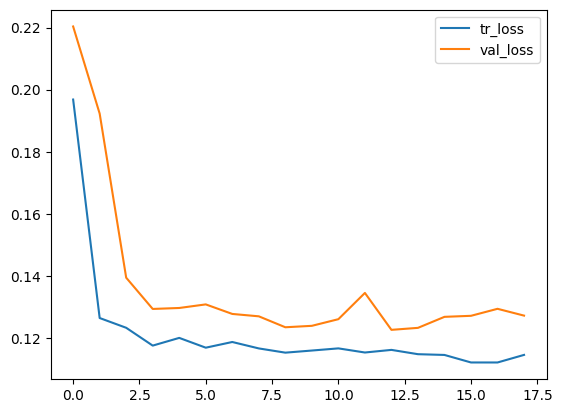

In [27]:
import pandas as pd
pd.DataFrame(history).plot()

(torch.Size([3, 224, 224]), tensor([41.1231, 45.7261, 85.6328, 74.0879]))

In [54]:
test_img.shape, img.shape

(torch.Size([3, 224, 224]), (224, 224, 3))

Text(0.5, 1.0, 'Original bbox')

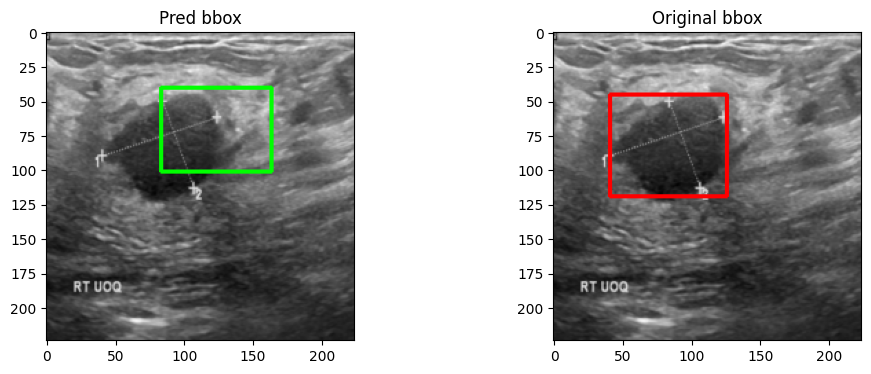

In [59]:
test_img, test_bbox = ben_test_loader.dataset.dataset.__getitem__(1)

net.eval()

with torch.no_grad():
    pred_test = net(test_img.unsqueeze(0).to(device))

img = test_img.permute(1,2,0).cpu().numpy()

h_img, w_img, _ = img.shape

# prediction
x, y, w, h = pred_test[0]

x = int(x.item() * w_img)
y = int(y.item() * h_img)
w = int(w.item() * w_img)
h = int(h.item() * h_img)


# ground truth
tx, ty, tw, th = test_bbox

tx = int(tx )
ty = int(ty )
tw = int(tw )
th = int(th )

bounded_img = cv2.rectangle(
    img.copy(),
    (x, y),
    (x+w, y+h),
    (0, 255, 0),
    2
)
bounded_img2 = cv2.rectangle(
    img.copy(),
    (tx, ty),
    (tx+tw, ty+th),
    (255,0, 0, 0),
    2
)
_, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].imshow(bounded_img)
ax[0].set_title("Pred bbox")
ax[1].imshow(bounded_img2)
ax[1].set_title("Original bbox")


